## Q1

In [1]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()

X = iris.data
y = iris.target

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:")

print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

print("\nTotal Variance Explained:",
      sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
PC1: 0.9246187232017302
PC2: 0.053066483117066035

Total Variance Explained: 0.9776852063187963


## Q2

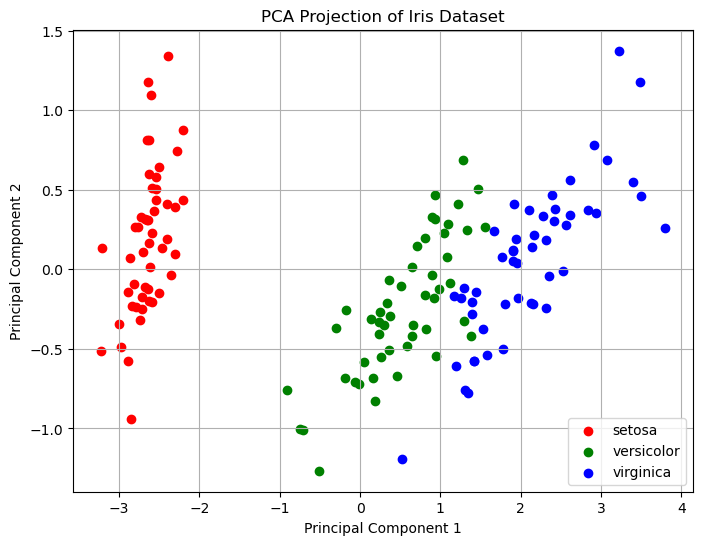

In [2]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(8,6))

colors = ["red","green","blue"]

for i, color in enumerate(colors):

    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        color=color,
        label=iris.target_names[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection of Iris Dataset")

plt.legend()

plt.grid(True)

plt.show()

## Q3

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

df = pd.DataFrame({

    "rating":np.random.uniform(3,5,100),
    "cost":np.random.randint(300,2000,100),
    "votes":np.random.randint(20,1000,100),
    "delivery_time":np.random.randint(20,80,100),
    "reviews":np.random.randint(10,500,100),
    "discount":np.random.randint(0,60,100),
    "tables":np.random.randint(5,40,100),
    "staff":np.random.randint(5,30,100),
    "parking":np.random.randint(0,2,100),
    "online_orders":np.random.randint(0,2,100)

})

In [4]:
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()

X = scaler.fit_transform(df)

# PCA (3 components)
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(100, 3)


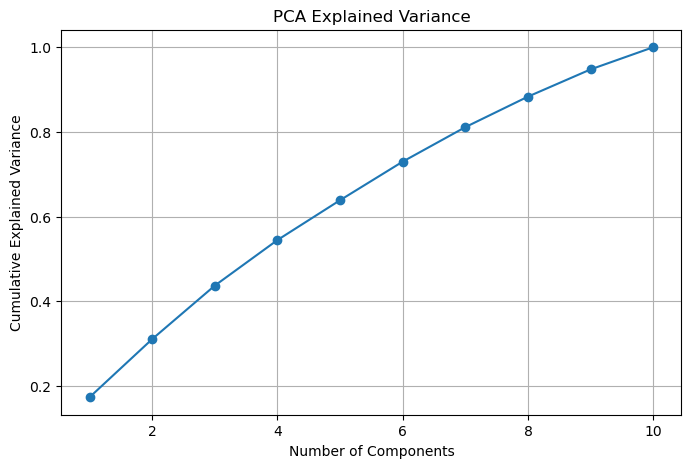

In [5]:
pca_all = PCA()

pca_all.fit(X)

cum_var = np.cumsum(
    pca_all.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker="o"
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

## Q4

c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


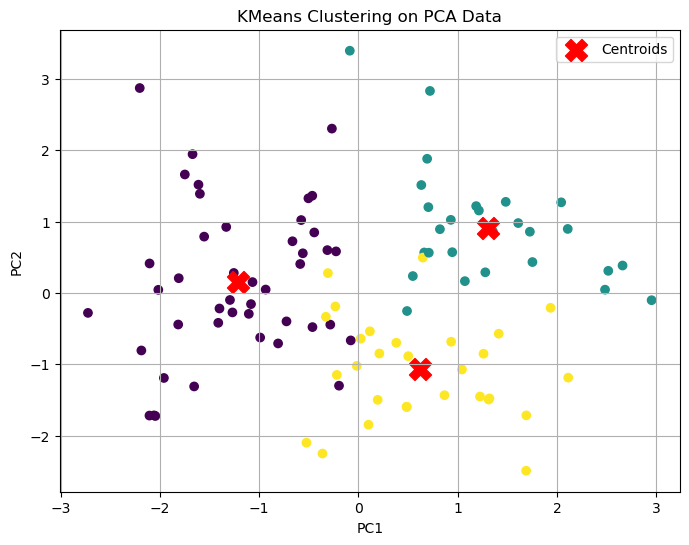

In [7]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("KMeans Clustering on PCA Data")

plt.legend()

plt.grid(True)

plt.show()

## Q5

In [8]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_pca,
    clusters
)

print("Silhouette Score:")

print(score)

Silhouette Score:
0.287132788723037
